# Week 06: Stats for Business: Is the Price Right?

You just joined the pricing team at a car-listing marketplace. Your manager has a few questions and one rule: **every claim needs a number, and every number needs a reason to trust it.**

**Data:** `cars.csv`: about 12,000 car trims (1990–2017) with specs and sticker price (MSRP). Source: [Car Features and MSRP (Kaggle)](https://www.kaggle.com/datasets/CooperUnion/cardataset). It's real data, so it's messy.

**What you'll practice** (all from this week's lecture):
- Cleaning before describing
- Mean vs median, skew, log transforms
- z-scores
- Bootstrap confidence intervals
- One- and two-sample tests, and picking the right one
- Confounding, and significant vs important

**How to answer:** Fill in the code cells, then write 1–3 sentences in each **Answer:** cell. Code without an interpretation is only half the job.

Plan for about 2–3 hours. 🚀 questions are optional stretch.

## Setup

In [30]:
# run this first if you dont have them installed in your env
!pip install pandas numpy matplotlib scipy

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pd.set_option("display.max_columns", None)
rng = np.random.default_rng(42)  # use rng for all random sampling so your results are reproducible

df = pd.read_csv("../data/cars.csv")
print(df.shape)
df.head()

(11914, 15)


,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Compact,Convertible,28,18,3916,34500


---
## Part 1: Can you trust this data?

### Q1. Find the problems before you average anything

This dataset has **at least five** real problems. Find them, fix or flag each one, and build a cleaned DataFrame called `clean`. You'll use `clean` for the rest of the notebook.

Use your Week 02 cleaning checklist. Some nudges, in no particular order:
- Count things twice.
- The most common value in a column can be more suspicious than the largest one.
- Would you print every max value in a sales brochure?
- Missing values usually have a reason. *Who* is missing?
- Is every number in a column measured in the same unit?
- Does every column vary at the level you'd expect?
- Not everything weird is wrong.

For each problem, decide: **drop it, set it to NaN, flag it, or leave it**. Dropping whole rows is the last resort, because a row with a bad price may still have a good MPG.

(11194, 17) 747


**Cleaning log**

| # | Problem | How I found it | Rows affected | What I did | Why |
|---|---|---|---|---|---|
| 1 | Duplicate rows | `df.duplicated().sum()` returned 720 | 720 | Dropped them | Exact copies add no information and would double-count those cars in every average. |
| 2 | `MSRP = 2000` placeholder | `value_counts()` on MSRP: 2000 appears 1,036 times and the next most common price only 19 times. All of them are 1990–2000 models. | 1,036 in the raw data (747 after dedup) | Set MSRP to NaN and added a `msrp_is_placeholder` flag | $2,000 for a 1993 Dodge RAM isn't a real price, so it would drag the average down. The rows still have valid MPG, HP and other columns, so I kept them. |
| 3 | `highway MPG = 354` (impossible value) | Sorted by highway MPG. The Audi A6 2017 shows 354 against a city MPG of 24. | 1 | Set highway MPG to NaN for that row | It's almost certainly a typo, and I can't know the true value. The rest of the row is fine, so I didn't drop it. |
| 4 | Electric cars report MPGe, not MPG (mixed units) | Highway MPG is 100+ for electric cars versus about 26 for gas cars, and `groupby` on Engine Fuel Type confirmed it. | 66 in the raw data | Added an `is_electric` flag and kept the values | The numbers are real but measured in a different unit. Mixing them with gas MPG inflates averages, so I exclude EVs from MPG comparisons. |
| 5 | `Popularity` doesn't vary at the car level | `groupby("Make")["Popularity"].nunique()` returned 1 for all 48 makes. | All rows | Left as is, flagged in the notes | It's a make-level number, not a per-car one, so it can't tell cars of the same make apart. I won't use it as a car-level feature. |

**Also noted (not in the five):** missing `Engine HP` and `Engine Cylinders` are mostly electric cars, so the missingness has a reason. I left them as NaN and did not impute. The 19 `"UNKNOWN"` transmissions were set to NaN.

In [43]:
# Build your cleaned DataFrame. Start from a copy so df stays untouched.
clean = df.copy()
clean.columns = clean.columns.str.strip().str.lower().str.replace(" ", "_")  # freebie: snake_case names

# 1. duplicates
clean = clean.drop_duplicates()

# 2. MSRP placeholder
clean["msrp_is_placeholder"] = clean["msrp"].eq(2000)
clean.loc[clean["msrp_is_placeholder"], "msrp"] = np.nan

# 3. impossible highway MPG (Audi A6 = 354)
clean.loc[clean["highway_mpg"] > 200, "highway_mpg"] = np.nan

# 4. EVs report MPGe, not MPG
clean["is_electric"] = clean["engine_fuel_type"].eq("electric")

# extra: UNKNOWN transmission -> NaN
clean["transmission_type"] = clean["transmission_type"].replace("UNKNOWN", np.nan)

In [44]:
# Checkpoint: run this before moving on.
print(clean.shape)
print(clean.isna().sum()[clean.isna().sum() > 0])
# Fewer than ~10,000 rows? You probably dropped too much. Go back and use NaN or a flag instead.

(11194, 17)
engine_fuel_type       3
engine_hp             69
engine_cylinders      30
transmission_type     12
number_of_doors        6
highway_mpg            1
msrp                 747
dtype: int64


---
## Part 2: Describe

### Q2. What does a "typical" car cost?

Your manager wants one number for "typical price" on the homepage.

a) Compute the mean and median MSRP. Which is bigger, and why?

b) Plot a histogram of MSRP, then a histogram of `np.log10(msrp)`. Describe each shape in a few words.

c) What percent of cars cost more than the mean?

d) Which number belongs on the homepage? Why?

Mean:   $44,789
Median: $31,870


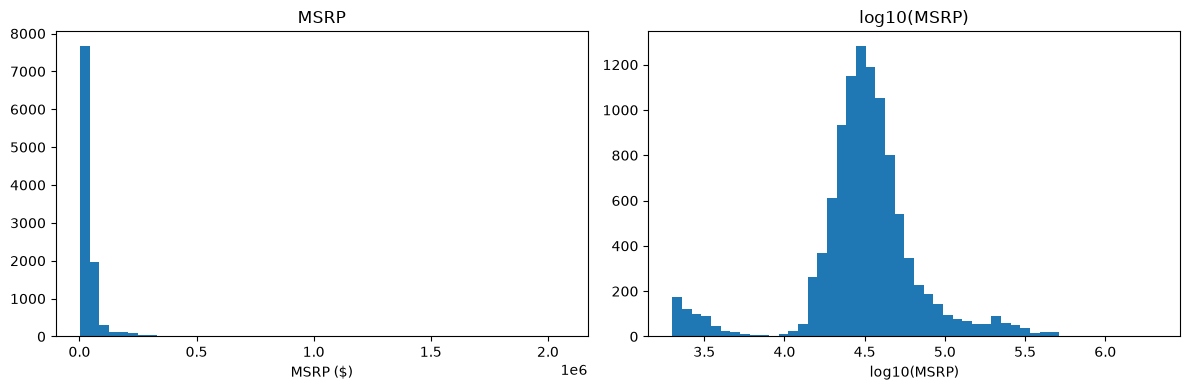

24.4% of cars cost more than the mean


In [45]:
# a) mean and median
msrp = clean["msrp"].dropna()
mean_msrp = msrp.mean()
median_msrp = msrp.median()
print(f"Mean:   ${mean_msrp:,.0f}")
print(f"Median: ${median_msrp:,.0f}")

# b) two histograms side by side
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(msrp, bins=50)
axes[0].set_title("MSRP")
axes[0].set_xlabel("MSRP ($)")
axes[1].hist(np.log10(msrp), bins=50)
axes[1].set_title("log10(MSRP)")
axes[1].set_xlabel("log10(MSRP)")
plt.tight_layout()
plt.show()

# c) share of cars above the mean
pct_above = (msrp > mean_msrp).mean() * 100
print(f"{pct_above:.1f}% of cars cost more than the mean")

**Answer:**
**a)** Mean = \$44,789, median = \$31,870. The mean is bigger because MSRP is right-skewed: a few very expensive cars (Bugatti, Maybach, Lamborghini, up to ~\$2M) pull the mean up, while the median is just the middle car and barely moves.

**b)** Raw MSRP is extremely right-skewed. Almost every car is crammed into the first couple of bins, with a long thin tail out to \$2M. log10(MSRP) is roughly bell-shaped and centered around 4.5 (~\$32k), with a small bump on the left from cheap 1990s cars and a thin right tail from luxury cars.

**c)** Only 24.4% of cars cost more than the mean, so about 3 in 4 cars are cheaper than the "average" price.

**d)** The median. It reflects what a typical shopper would actually pay and isn't distorted by a handful of supercars. The mean overstates the typical price by about \$13k, and 3 out of 4 cars cost less than it, so it would mislead buyers.

### Q3. Fuel-efficient *for its size*?

Two 2017 cars:
- **Honda Civic** (Compact): 42 highway MPG
- **Volvo S90** (Large): 34 highway MPG

The Civic wins on raw MPG, but large cars are heavier. Which one is more impressive *for its class*?

a) For 2017 cars (only the MPG values you trust after Q1), compute the mean and standard deviation of highway MPG for each `vehicle_size`.

b) Compute each car's z-score within its own size class.

c) Which is more fuel-efficient for its class? How unusual is each one?

In [46]:
# a) mean and std of highway_mpg by vehicle_size, 2017 only
cars17 = clean[(clean["year"] == 2017) & (~clean["is_electric"])].dropna(subset=["highway_mpg"])

size_stats = cars17.groupby("vehicle_size")["highway_mpg"].agg(["mean", "std", "count"])
print(size_stats.round(2))

# b) z = (value - class mean) / class std
cars17["z_in_class"] = cars17.groupby("vehicle_size")["highway_mpg"].transform(
    lambda s: (s - s.mean()) / s.std()
)

civic_z = (42 - size_stats.loc["Compact", "mean"]) / size_stats.loc["Compact", "std"]
s90_z   = (34 - size_stats.loc["Large", "mean"])   / size_stats.loc["Large", "std"]
print(f"Civic (Compact, 42 mpg): z = {civic_z:.2f}")
print(f"S90   (Large,   34 mpg): z = {s90_z:.2f}")

               mean   std  count
vehicle_size                    
Compact       30.88  6.05    509
Large         22.99  3.49    468
Midsize       29.41  5.45    638
Civic (Compact, 42 mpg): z = 1.84
S90   (Large,   34 mpg): z = 3.15


**Answer:**
**a)** 2017 highway MPG by size (gas cars only, EVs excluded since they report MPGe): Compact mean 30.9 (std 6.0), Midsize 29.4 (std 5.5), Large 23.0 (std 3.5).

**b)** Civic: z = (42 − 30.9) / 6.0 ≈ **1.84**. S90: z = (34 − 23.0) / 3.5 ≈ **3.15**.

**c)** The **Volvo S90** is more impressive for its class. The Civic is about 1.8 standard deviations above the average compact: good, but plenty of compacts get close. The S90 is over 3 standard deviations above the average large car, which is rare: if large-car MPG were roughly normal, fewer than 1 in 1,000 would be that far above the mean. Raw MPG favors the Civic; MPG relative to its class favors the S90.

---
## Part 3: Uncertainty

### Q4. How sure are we about the median price?

The 2017 cars are one snapshot of the market. With a slightly different set of cars, the median would move. A bootstrap shows how much.

a) Compute the median MSRP of 2017 cars.

b) Bootstrap it: resample the 2017 prices **with replacement** 5,000 times and take the median each time. Plot the 5,000 medians and report the 95% interval (2.5th and 97.5th percentiles).

c) Repeat for 2017 cars from **one make** with fewer than 50 cars that year (your choice). Is the interval wider or narrower? Why?

d) Explain the interval from (b) in one sentence a manager would understand.

2017 cars: n = 1624, median = $36,738
95% interval: $35,940 to $37,683  (width $1,743)


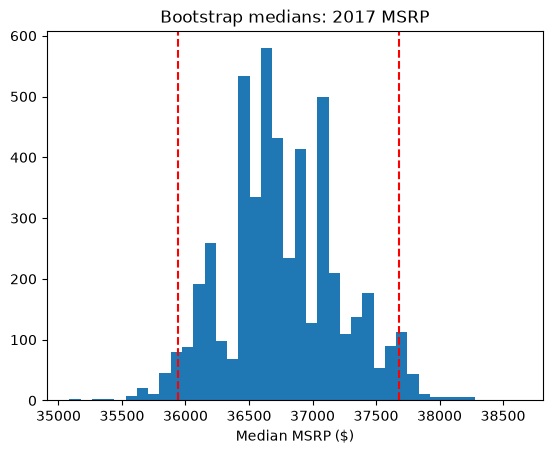

make
Volkswagen    61
Dodge         51
Subaru        46
Lincoln       46
Kia           43
Hyundai       42
Buick         39
Acura         36
Lexus         34
Mitsubishi    29
Infiniti      28
Porsche       25
Chrysler      24
Mazda         24
Volvo         23
FIAT          19
Land Rover    11
Maserati      10
Genesis        3
Lotus          1
Name: count, dtype: int64
Volvo 2017: n = 23, median = $46,350
95% interval: $41,750 to $50,450  (width $8,700)


In [47]:
def bootstrap_median(values, n_boot=5000):
    """Return an array of n_boot bootstrap medians."""
    values = np.asarray(values)
    return np.array([
        np.median(rng.choice(values, size=len(values), replace=True))
        for _ in range(n_boot)
    ])

# a, b)
prices17 = clean.loc[clean["year"] == 2017, "msrp"].dropna()
print(f"2017 cars: n = {len(prices17)}, median = ${prices17.median():,.0f}")

boot17 = bootstrap_median(prices17)
lo, hi = np.percentile(boot17, [2.5, 97.5])
print(f"95% interval: ${lo:,.0f} to ${hi:,.0f}  (width ${hi - lo:,.0f})")

plt.hist(boot17, bins=40)
plt.axvline(lo, color="red", linestyle="--")
plt.axvline(hi, color="red", linestyle="--")
plt.title("Bootstrap medians: 2017 MSRP")
plt.xlabel("Median MSRP ($)")
plt.show()

# c)
print(clean[clean["year"] == 2017]["make"].value_counts().tail(20))  # pick a make with < 50

volvo17 = clean.loc[(clean["year"] == 2017) & (clean["make"] == "Volvo"), "msrp"].dropna()
boot_volvo = bootstrap_median(volvo17)
vlo, vhi = np.percentile(boot_volvo, [2.5, 97.5])
print(f"Volvo 2017: n = {len(volvo17)}, median = ${volvo17.median():,.0f}")
print(f"95% interval: ${vlo:,.0f} to ${vhi:,.0f}  (width ${vhi - vlo:,.0f})")

**Answer:**
**a)** The median MSRP of 2017 cars is about \$36,738 (n = 1,624).

**b)** The bootstrap medians form a narrow, roughly bell-shaped pile centered near \$36.7k. The 95% interval is about **\$35,940 to \$37,683**.

**c)** For Volvo (23 cars in 2017), the median is \$46,350 with a 95% interval of about **\$41,750 to \$50,450**. That's about 5× wider. With only 23 cars, each resample can swap in or out a few very cheap or very expensive trims, so the median jumps around a lot. With 1,624 cars, no handful of cars can move the middle much. Smaller samples mean more uncertainty.

**d)** If we looked at a slightly different set of 2017 cars, the typical price would very likely still land between about \$36,000 and \$37,700, so "about \$37k" is a solid number to quote.

---
## Part 4: Testing

### Q5. Can marketing say "our 2017 compacts average over 30 MPG"?

a) Write H₀ and Hₐ. One-sided or two-sided? Why?

b) How many cars are in the sample, and what does the distribution look like? Is a t-test reasonable here?

c) Run a one-sample t-test at α = 0.05 (`stats.ttest_1samp(..., alternative="greater")`). State the conclusion in plain English.

d) **Independence check.** Tests assume each row is an independent observation. Count how many rows each `make` + `model` has in this sample. Then average to one row per model and rerun the test. What changed, and which version do you trust more?

n = 509, mean = 30.88, std = 6.05, median = 30.0


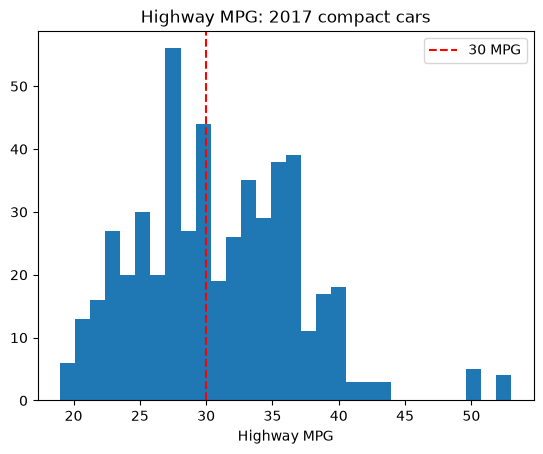

Row-level: t = 3.28, p = 0.0005
make        model   
Toyota      Tacoma      27
Chevrolet   Corvette    24
Nissan      Frontier    22
            370Z        17
Porsche     911         14
Honda       Civic       13
Audi        A3          12
Volkswagen  Golf GTI    10
Nissan      Juke        10
Chevrolet   Sonic       10
dtype: int64
85 unique models
Model-level: n = 85, mean = 31.69, t = 2.58, p = 0.0059


In [48]:
from scipy import stats

# b) sample: 2017 compact cars (MPG you trust); n, mean, histogram
compact17 = clean[
    (clean["year"] == 2017)
    & (clean["vehicle_size"] == "Compact")
    & (~clean["is_electric"])
].dropna(subset=["highway_mpg"])

mpg = compact17["highway_mpg"]
print(f"n = {len(mpg)}, mean = {mpg.mean():.2f}, std = {mpg.std():.2f}, median = {mpg.median():.1f}")

plt.hist(mpg, bins=30)
plt.axvline(30, color="red", linestyle="--", label="30 MPG")
plt.title("Highway MPG: 2017 compact cars")
plt.xlabel("Highway MPG")
plt.legend()
plt.show()

# c) one-sample t-test vs 30
t, p = stats.ttest_1samp(mpg, 30, alternative="greater")
print(f"Row-level: t = {t:.2f}, p = {p:.4f}")

# d) rows per make+model, then one row per model and retest
per_model_counts = compact17.groupby(["make", "model"]).size().sort_values(ascending=False)
print(per_model_counts.head(10))
print(f"{len(per_model_counts)} unique models")

model_means = compact17.groupby(["make", "model"])["highway_mpg"].mean()
t2, p2 = stats.ttest_1samp(model_means, 30, alternative="greater")
print(f"Model-level: n = {len(model_means)}, mean = {model_means.mean():.2f}, t = {t2:.2f}, p = {p2:.4f}")

**Answer:**
**a)** H₀: μ ≤ 30 (2017 compacts average 30 MPG or less). Hₐ: μ > 30. One-sided, because marketing only wants to claim "over 30". Finding the mean is *below* 30 wouldn't support the claim either way.

**b)** n = 509 cars (gas only, EVs excluded since they report MPGe). Mean 30.9, median 30, std 6.0. The distribution is roughly bell-shaped with a mild right skew (a tail of high-MPG hybrids up to ~53). With n = 509, the Central Limit Theorem makes the sample mean close to normal, so a t-test is reasonable.

**c)** t = 3.28, p ≈ 0.0005 < 0.05, so we reject H₀. In plain English: if compacts really averaged 30 MPG or less, a sample average this high would almost never happen by chance, so the data support "over 30 MPG". But it's only about 0.9 MPG over, which is statistically clear but not a big margin.

**d)** The 509 rows are only 85 distinct models. Some models have many trim rows (Toyota Tacoma 27, Chevy Corvette 24, Nissan Frontier 22), so the rows aren't independent: one model's MPG gets counted many times. Averaging to one row per model gives n = 85, mean 31.7, t = 2.58, p ≈ 0.006. The conclusion holds (still significant), but the p-value is about 10× larger because the effective sample size is much smaller. I trust the per-model version more: it treats each model as one independent data point instead of letting heavily-trimmed models like the Tacoma and Corvette (both low-MPG) dominate the average.

### Q6. Do manual cars cost less? (the big one)

A sales rep says: *"Manual cars are way cheaper. We should push manuals to budget shoppers."*

Compare `AUTOMATIC` vs `MANUAL` only.

a) Compare the median MSRP of the two groups.

b) Before believing it, compare the `year` of manual vs automatic cars. What do you notice?

c) Redo (a) using only 2015–2017 cars, then within each `vehicle_size`. For 2015–17 compacts, use the Mann–Whitney U test (`stats.mannwhitneyu(auto, manual)`) to compare prices.

- What do the p-value and medians suggest?

d) Write one sentence back to the sales rep.

                    median  count
transmission_type                
AUTOMATIC          33620.0   7635
MANUAL             21875.0   2184
                          mean     25%     50%     75%
transmission_type                                     
AUTOMATIC          2011.843340  2009.0  2015.0  2016.0
MANUAL             2006.475503  1998.0  2008.0  2015.0


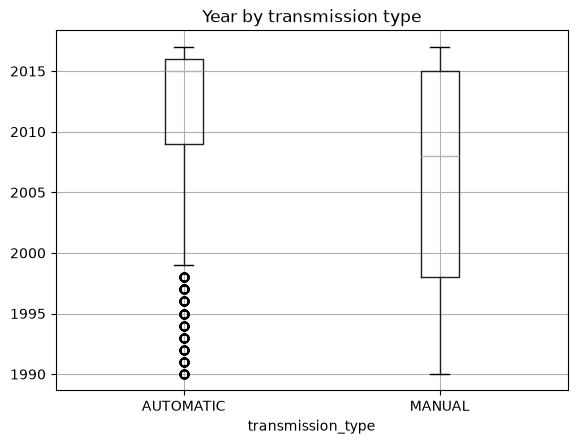

                    median  count
transmission_type                
AUTOMATIC          37065.0   4511
MANUAL             26905.0    813
                     median              count       
transmission_type AUTOMATIC   MANUAL AUTOMATIC MANUAL
vehicle_size                                         
Compact             25995.0  25860.0      1119    589
Large               44400.0  38395.0      1473     26
Midsize             37980.0  26920.0      1919    198
Compacts: auto median $25,995 (n=1119), manual median $25,860 (n=589), p = 0.205


In [49]:
# a) compare median MSRP by transmission type
am = clean[clean["transmission_type"].isin(["AUTOMATIC", "MANUAL"])]
print(am.groupby("transmission_type")["msrp"].agg(["median", "count"]))

# b) compare year by transmission type
print(am.groupby("transmission_type")["year"].describe()[["mean", "25%", "50%", "75%"]])
am.boxplot(column="year", by="transmission_type")
plt.title("Year by transmission type"); plt.suptitle("")
plt.show()

# c) compare 2015-2017 medians overall and within each vehicle_size
recent = am[am["year"].between(2015, 2017)]
print(recent.groupby("transmission_type")["msrp"].agg(["median", "count"]))
print(recent.pivot_table(index="vehicle_size", columns="transmission_type",
                         values="msrp", aggfunc=["median", "count"]))

# For 2015-17 compacts, test automatic vs manual prices with:
compact = recent[recent["vehicle_size"] == "Compact"].dropna(subset=["msrp"])
auto   = compact.loc[compact["transmission_type"] == "AUTOMATIC", "msrp"]
manual = compact.loc[compact["transmission_type"] == "MANUAL", "msrp"]
u, p = stats.mannwhitneyu(auto, manual)
print(f"Compacts: auto median ${auto.median():,.0f} (n={len(auto)}), "
      f"manual median ${manual.median():,.0f} (n={len(manual)}), p = {p:.3f}")

**Answer:**
**a)** Median MSRP: automatic \$33,620 vs manual \$21,875. At first glance, manuals look about \$12k cheaper.

**b)** Manuals are much older: median year 2008 vs 2015 for automatics, and manual years spread way back into the 1990s. Older cars have lower prices (older list prices, before inflation), so part of the "manual discount" is really an "old car discount." Year is a confounder.

**c)** Restricting to 2015–17 shrinks the gap but doesn't erase it overall (\$37,065 vs \$26,905). Within each size, the picture changes:
- **Compact:** \$25,995 vs \$25,860, basically identical.
- **Midsize:** \$37,980 vs \$26,920, a real gap.
- **Large:** \$44,400 vs \$38,395, but only 26 manual large cars, so it's shaky.

For 2015–17 compacts, Mann–Whitney gives p ≈ 0.20 > 0.05, so we can't conclude compact manuals and automatics differ in price. The medians are within about \$135 of each other. The big overall gap comes mostly from *which* cars are manual (older, smaller, cheaper segments), not from the transmission itself.

**d)** "Manuals look cheaper mainly because they're older and smaller cars. Among recent compacts, manual and automatic prices are basically the same, so pushing manuals won't save budget shoppers much."

### Q7. Significant ≠ important

Among cars whose MPG you trust, 4-door cars get better highway MPG than 2-door cars.

a) Run a Welch t-test. Report the difference in means and the p-value.

b) Translate the difference into dollars. Assume 12,000 miles/year and \$3.50/gallon. How much does the average 4-door driver save per year?

c) Now pretend you only had **30 cars per group.** Draw 30 random 4-door and 30 random 2-door cars, run the same test, and repeat 1,000 times. What fraction of those tests come out significant (p < 0.05)?

d) Would you put "4-door cars are significantly more fuel-efficient" in an ad? What would you say instead?

In [50]:
# a) Welch t-test, 4-door vs 2-door
trusted = clean[~clean["is_electric"]].dropna(subset=["highway_mpg"])
four = trusted.loc[trusted["number_of_doors"] == 4, "highway_mpg"].values
two  = trusted.loc[trusted["number_of_doors"] == 2, "highway_mpg"].values

t, p = stats.ttest_ind(four, two, equal_var=False)
diff = four.mean() - two.mean()
print(f"4-door: n={len(four)}, mean={four.mean():.2f} | 2-door: n={len(two)}, mean={two.mean():.2f}")
print(f"Difference = {diff:.2f} MPG, t = {t:.2f}, p = {p:.2e}")

# b) yearly gas cost = miles * price_per_gallon / mpg
miles, price = 12_000, 3.50
cost_two  = miles * price / two.mean()
cost_four = miles * price / four.mean()
print(f"2-door: ${cost_two:,.0f}/yr | 4-door: ${cost_four:,.0f}/yr | savings: ${cost_two - cost_four:,.0f}/yr")

# c) simulation
n_sims, hits = 1000, 0
for _ in range(n_sims):
    s4 = rng.choice(four, 30, replace=False)
    s2 = rng.choice(two, 30, replace=False)
    if stats.ttest_ind(s4, s2, equal_var=False).pvalue < 0.05:
        hits += 1
print(f"{hits / n_sims:.1%} of tests were significant with n=30 per group")

4-door: n=7897, mean=26.80 | 2-door: n=2873, mean=25.26
Difference = 1.55 MPG, t = 11.93, p = 2.11e-32
2-door: $1,663/yr | 4-door: $1,567/yr | savings: $96/yr
15.8% of tests were significant with n=30 per group


**Answer:**
**a)** 4-door mean 26.8 MPG vs 2-door 25.3 MPG, a difference of about **1.5 MPG**. Welch t-test: t ≈ 11.9, p ≈ 2×10⁻³². Extremely significant.

**b)** At 12,000 miles/year and \$3.50/gal: a 2-door costs about \$1,663/yr in gas, a 4-door about \$1,567/yr. The average 4-door driver saves only **about \$96/year**, roughly \$8/month.

**c)** With only 30 cars per group, just **~15%** of the 1,000 tests were significant. The tiny p-value in (a) comes from the huge sample size (~10,000 cars), not from a big effect. With a realistic sample, you'd usually miss the difference entirely.

**d)** No. "Significantly" sounds like "a lot," but the real difference is 1.5 MPG, about \$96 a year. It's statistically real but practically small. I'd either skip the claim or say something honest and concrete, like: "4-door models average about 1.5 MPG better on the highway, around \$100 a year in gas savings."

---
## Part 5: Communicate

### Q8. Your memo to the pricing manager

Write 4–6 sentences. Include:
- Your answer to "do manual cars cost less?", with at least one number
- One other finding from this notebook that matters for pricing
- One limitation of this data a manager should know about

No unexplained jargon: if you say "significant," say what it means.

**Memo:**
**Memo:**

Manual cars look about \$12,000 cheaper than automatics at first glance (median \$21,875 vs \$33,620), but most of that gap exists because manuals in our data are older (median model year 2008 vs 2015) and tend to be smaller cars. When we compare like with like, 2015–17 compact cars, the medians are nearly identical (\$25,860 manual vs \$25,995 automatic), and the difference is small enough that it could easily be random chance, so we should not tell budget shoppers that choosing a manual will save them money. For the homepage "typical price," we should use the median (about \$31,900) rather than the average (about \$44,800), because a handful of very expensive supercars pull the average up so far that 3 out of 4 cars cost less than it. One limitation to keep in mind: about 1,000 older cars (mostly 1990–2000) had a placeholder price of \$2,000 instead of a real price, so we excluded those prices, which means our price conclusions mainly reflect newer cars. The data also lists many trims of the same model as separate rows, so popular models with lots of trims carry extra weight in any average.

---
## 🚀 Stretch (optional)

### 🚀 S1. Horsepower and price

a) Compute the correlation between `engine_hp` and `msrp` three ways: Pearson, Pearson with `np.log10(msrp)`, and Spearman. Why do they differ?

b) Scatter plot HP vs MSRP with a log y-axis (`plt.yscale("log")`).

c) Does adding horsepower *cause* a higher price? Name one lurking variable.

In [41]:
# S1

### 🚀 S2. Is transmission tied to vehicle size?

For 2015–2017 cars (automatic and manual only), build a crosstab of `vehicle_size` × `transmission_type` and run a chi-square test (`stats.chi2_contingency`). How does this connect to Q6?

In [42]:
# S2